# Dogs vs. Cats: Exploratory Data Analysis

This is the first of three notebooks in a compact transfer-learning case study on the
**Dogs vs. Cats** photograph dataset. Before training anything, it is worth establishing
what the data actually looks like, not as a ritual but because several specific
properties of this dataset directly determine choices made in the next notebook.

Unlike MNIST, where every image is a centered 28x28 grayscale digit, these are roughly
25,000 real photographs scraped from the web. They vary in resolution, aspect ratio,
subject scale, lighting, and how much of the frame the animal actually occupies. That
variation is the whole reason a pretrained backbone is the right tool here.

The archive ships as one folder per class with no train/test division of its own, so
this notebook is responsible for carving out every split the project uses.

We will:

* Confirm the class balance rather than trusting the dataset description.
* Check that every file is actually a decodable image, because several are not what their extension claims.
* Look at raw images from both classes, to see the range of poses and framing we are asking a model to handle.
* Survey image dimensions and aspect ratios, which motivates the resize/crop strategy in the augmentation pipeline.
* Produce a stratified train/validation/test split, saved to disk so the later notebooks provably share the same partition.

## Imports

In [1]:
from collections import Counter

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from catsdogs.dataset import class_balance, filter_loadable, list_image_paths, stratified_split

DATA_DIR = Path("../data/raw/PetImages")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## Class balance

The images arrive in two folders, `Cat/` and `Dog/`, with filenames that are bare
numbers restarting from zero in each folder. The label therefore lives in the directory
name and nowhere else, which is why `catsdogs.dataset` derives it from the parent
directory rather than parsing the filename.

The dataset is advertised as an even 12,500 per class. It costs one cell to verify
that, and the answer matters: a balanced dataset means plain accuracy is a defensible
headline metric, and it means a stratified split is a cheap safeguard rather than a
necessity.

24959 images total: {'cat': 12490, 'dog': 12469}


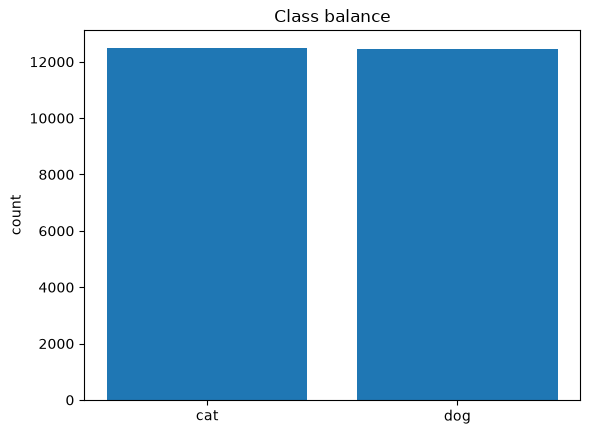

In [2]:
paths = list_image_paths(DATA_DIR)
counts = class_balance(paths)
print(f"{len(paths)} images total: {counts}")

plt.bar(counts.keys(), counts.values())
plt.ylabel("count")
plt.title("Class balance")
plt.show()

## File integrity

This section exists because this particular archive has a reputation for containing a
couple of unreadable files, and a single corrupt image is enough to kill a DataLoader
worker several minutes into an epoch. It is far cheaper to decode everything once now
than to debug that later.

Two things are worth separating here. The first is whether a file decodes at all. The
second is what format it actually is, which turns out not to match the `.jpg` extension
for a noticeable minority of the files.

In [3]:
formats = Counter()
for path in paths:
    with Image.open(path) as image:
        formats[image.format] += 1

print("actual formats, regardless of the .jpg extension:")
for name, count in formats.most_common():
    print(f"  {name:5s} {count:6d}")

loadable, rejected = filter_loadable(paths)
print(f"\n{len(rejected)} of {len(paths)} files failed to decode")
for path in rejected:
    print(f"  {path}")

actual formats, regardless of the .jpg extension:
  JPEG   24737
  BMP      172
  GIF       46
  PNG        4



0 of 24959 files failed to decode


Two findings, one benign and one that would have been a real trap.

The benign one is that nothing fails to decode. The two notoriously corrupt files that
this archive is known for have already been removed by whoever packaged this copy, which
also explains why the per-class counts land slightly under the advertised 12,500. The
integrity filter stays in the pipeline anyway, since it costs one pass and removes an
entire category of mid-training failure.

The trap is that several hundred files are not JPEGs at all. They are BMP, GIF, and PNG
data sitting behind a `.jpg` extension. This is harmless here only because the pipeline
loads images through PIL, which sniffs the actual file header and ignores the extension.
A pipeline built on a decoder that trusts the extension, such as
`torchvision.io.read_image`, would fail on exactly these files. It is a good argument for
deciding what a file is by opening it rather than by reading its name.

## Sample images

A handful of images from each class. The point of this cell is not to confirm that cats
look like cats. It is to calibrate expectations about difficulty. Look for how often the
animal is partially occluded, off-center, small in frame, photographed alongside a
human, or lit badly. Those are the cases the error analysis in notebook 03 will return
to.

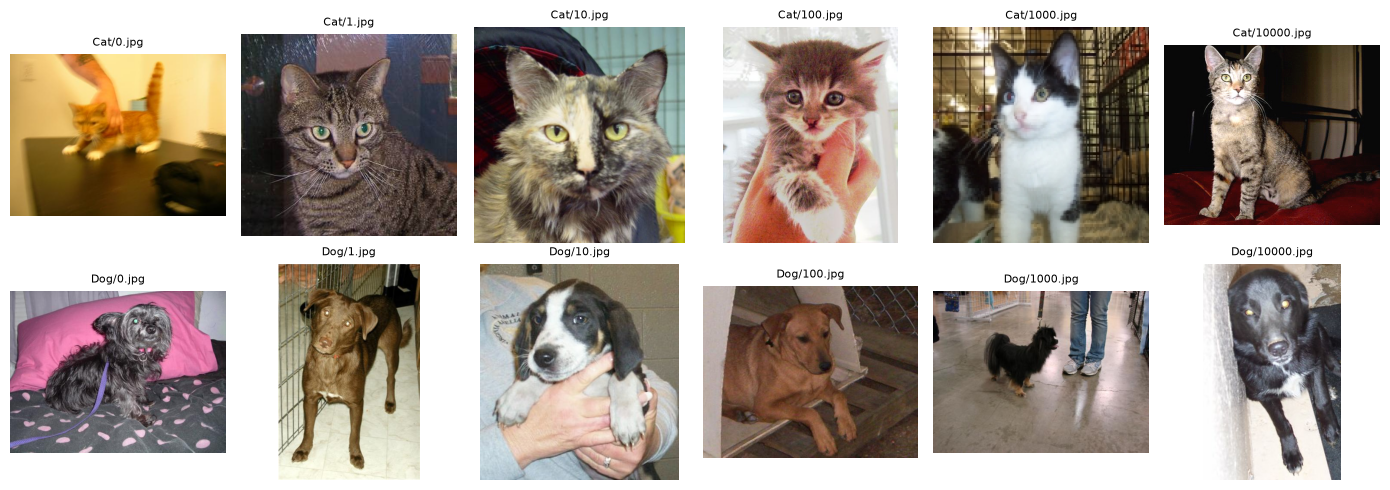

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for row, class_name in enumerate(["Cat", "Dog"]):
    examples = [p for p in loadable if p.parent.name == class_name][:6]
    for col, path in enumerate(examples):
        axes[row, col].imshow(Image.open(path).convert("RGB"))
        axes[row, col].set_title(f"{class_name}/{path.name}", fontsize=8)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

## Image dimensions and aspect ratio

This is the survey that actually drives a modeling decision. A pretrained ImageNet
backbone expects a fixed 224x224 input, so every image has to be resized, but *how*
depends on the shape of the distribution below.

If aspect ratios cluster tightly near 1.0, a naive resize distorts little and is fine.
The wider the spread, the more a plain `Resize((224, 224))` squashes subjects, and the
more a crop-based strategy is worth preferring. Sampling every 20th image is plenty to
characterize the distribution without opening 25,000 files.

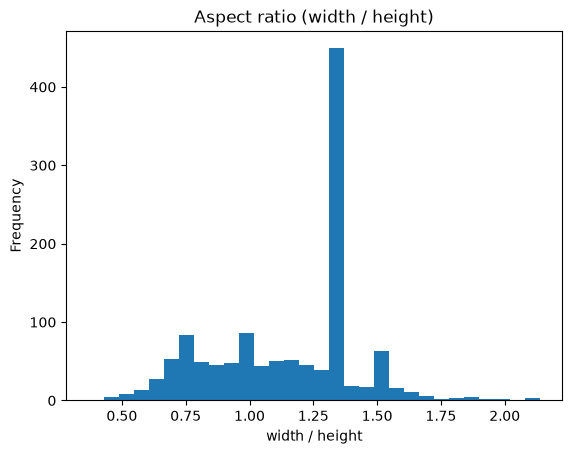

,width,height
count,1248.000000,1248.000000
mean,402.625801,359.828526
std,108.960909,96.767329
min,78.000000,70.000000
25%,320.000000,300.000000
50%,448.000000,375.000000
75%,500.000000,417.000000
max,500.000000,500.000000


In [5]:
sample = loadable[::20]  # every 20th image is enough to characterize the distribution
sizes = [Image.open(p).size for p in sample]
df_sizes = pd.DataFrame(sizes, columns=["width", "height"])

(df_sizes["width"] / df_sizes["height"]).plot(
    kind="hist", bins=30, title="Aspect ratio (width / height)"
)
plt.xlabel("width / height")
plt.show()

df_sizes.describe()

The takeaway feeds directly into `build_transforms` in `src/catsdogs/dataset.py`:
training uses `RandomResizedCrop`, which samples a random 80-100% region and resizes it
to 224x224. That doubles as augmentation and as a principled answer to non-square
inputs, since it crops rather than squashing. Validation and test use a plain
deterministic resize, because evaluation must not be stochastic.

## Train/validation/test split

A 70/15/15 stratified split into three sets rather than two.

The distinction between the validation and test sets is the point. Training saves the
checkpoint that scores best on the validation set, which means the validation score is
chosen as a maximum over every epoch and is therefore optimistically biased. Reporting
it as the headline result would be quietly overstating the model. The test set is
touched exactly once, in notebook 03, after the model is frozen, so its metrics are an
honest estimate of performance on unseen photographs.

This is worth the extra 15% precisely because the data is cheap and plentiful here.
Holding out roughly 3,700 images still leaves well over 17,000 to train on, which is
ample for fine-tuning a backbone whose features are already trained.

Stratification matters less on a balanced dataset than it would on a skewed one, but it
is nearly free and it removes sampling noise as an explanation for any class asymmetry
we see in the confusion matrix later.

The splits are written to `data/processed/` rather than recomputed per notebook. Both
later notebooks read these CSVs, so the model is never evaluated on an image it trained
on. That is a guarantee a shared random seed alone does not give you, since it silently
breaks the moment someone changes a split parameter in one notebook and not the other.

In [6]:
splits = stratified_split(loadable, val_fraction=0.15, test_fraction=0.15, seed=0)

for name, (split_paths, split_labels) in splits.items():
    print(f"{name:5s} {len(split_paths):6d} images, balance: {class_balance(split_paths)}")
    pd.DataFrame(
        {"path": [str(p) for p in split_paths], "label": split_labels}
    ).to_csv(PROCESSED_DIR / f"{name}_split.csv", index=False)

train  17471 images, balance: {'cat': 8743, 'dog': 8728}
val     3744 images, balance: {'cat': 1874, 'dog': 1870}
test    3744 images, balance: {'cat': 1873, 'dog': 1871}


## Closing notes

Three properties of this dataset shape everything that follows.

It is **balanced**, so accuracy is a meaningful headline number and the confusion matrix
should be roughly symmetric if the model is behaving.

It is **visually heterogeneous** (varied resolution, framing, and occlusion), which is
exactly the regime where fine-tuning pretrained ImageNet features beats training a small
CNN from scratch, since low-level edge and texture detectors transfer directly and do
not need to be relearned from 17,000 photographs.

And it is **not as clean as it looks**: file extensions do not reliably describe file
contents, which is a reminder that the integrity pass belongs in the pipeline rather
than in a one-off script.

Notebook 02 fine-tunes a pretrained ResNet18 on the training split produced above,
selecting its checkpoint against the validation split.